In [2]:
import numpy as np
import h5py
import time

import astropy.units as u
import astropy.cosmology.units as cu
import astropy.constants as const

import raytrace
import sys

rng = np.random.default_rng(seed=1)


['halo_0', 'halo_10293151', 'halo_10351684', 'halo_10422957', 'halo_10672584', 'halo_1068507', 'halo_10943032', 'halo_11069985', 'halo_11375033', 'halo_11823213', 'halo_11988378', 'halo_12045848', 'halo_12109950', 'halo_1263653', 'halo_1263657', 'halo_1263675', 'halo_12925051', 'halo_13388143', 'halo_13737851', 'halo_1431487', 'halo_14346920', 'halo_15304908', 'halo_15386300', 'halo_15543148', 'halo_1580995', 'halo_1580997', 'halo_15989517', 'halo_17283896', 'halo_17315356', 'halo_17469184', 'halo_1763505', 'halo_17902778', 'halo_18083789', 'halo_18373384', 'halo_18421127', 'halo_18602076', 'halo_18788091', 'halo_18909008', 'halo_19184395', 'halo_1921024', 'halo_2069291', 'halo_2213486', 'halo_2380799', 'halo_252455', 'halo_252459', 'halo_2637623', 'halo_2771226', 'halo_2892630', 'halo_2892634', 'halo_3020669', 'halo_3135769', 'halo_3238091', 'halo_3343359', 'halo_3457081', 'halo_3556542', 'halo_3656685', 'halo_3656694', 'halo_3758345', 'halo_3863281', 'halo_3863298', 'halo_4152102', '

In [5]:
from matplotlib import pyplot as plt

['halo_0', 'halo_10293151', 'halo_10351684', 'halo_10422957', 'halo_10672584', 'halo_1068507', 'halo_10943032', 'halo_11069985', 'halo_11375033', 'halo_11823213', 'halo_11988378', 'halo_12045848', 'halo_12109950', 'halo_1263653', 'halo_1263657', 'halo_1263675', 'halo_12925051', 'halo_13388143', 'halo_13737851', 'halo_1431487', 'halo_14346920', 'halo_15304908', 'halo_15386300', 'halo_15543148', 'halo_1580995', 'halo_1580997', 'halo_15989517', 'halo_17283896', 'halo_17315356', 'halo_17469184', 'halo_1763505', 'halo_17902778', 'halo_18083789', 'halo_18373384', 'halo_18421127', 'halo_18602076', 'halo_18788091', 'halo_18909008', 'halo_19184395', 'halo_1921024', 'halo_2069291', 'halo_2213486', 'halo_2380799', 'halo_252455', 'halo_252459', 'halo_2637623', 'halo_2771226', 'halo_2892630', 'halo_2892634', 'halo_3020669', 'halo_3135769', 'halo_3238091', 'halo_3343359', 'halo_3457081', 'halo_3556542', 'halo_3656685', 'halo_3656694', 'halo_3758345', 'halo_3863281', 'halo_3863298', 'halo_4152102', '

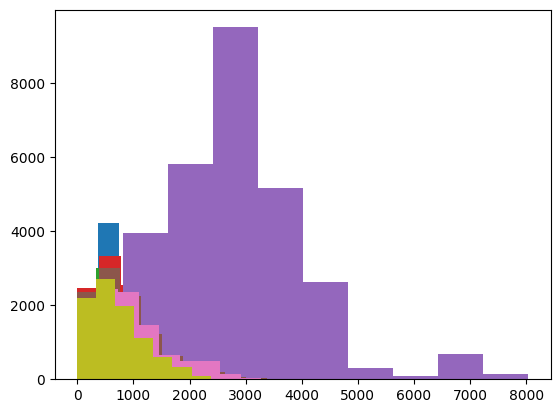

In [12]:

for sub_index in range(10):

    try:
        with h5py.File("outputs/dm_proto.hdf5", "r") as f:
            halo_ids = list(f.keys())
        print(halo_ids)
        halo_id = halo_ids[sub_index][5:]
        print(halo_id)
        
        with h5py.File("outputs/dm_proto.hdf5", "r") as f:
            halo = f['halo_'+halo_id]
            com = halo['GroupCM'][:]
        
            r200 = halo['Group_R_Crit200'][()]
            r500 = halo['Group_R_Crit500'][()]
            
            m200 = halo['Group_M_Crit200'][()]
            m500 = halo['Group_M_Crit500'][()]
            
        with h5py.File(f'tng_cache/snap_099/cutout_{halo_id}.hdf5', 'r') as f:
            gas_pos = raytrace.unwrap(f['PartType0/Coordinates'][:] - com) # ckpc
            gas_mass = f['PartType0/Masses'][:] # Msun
        
        r = np.linalg.norm(gas_pos, axis=-1)
        fgas200 = np.sum(gas_mass[r < r200])/m200
        fgas500 = np.sum(gas_mass[r < r500])/m500
        plt.hist(np.linalg.norm(gas_pos, axis=-1), weights=gas_mass)
        
    except FileNotFoundError as e:
        print(e)
    except KeyError as e:
        print(e)